# Extrapolate LCs at early times
See Section 2.1.2 in the paper.

We model the early phase of a SN using models described in Equation (2) and (3) in the paper.

In [37]:
import os
#COCO_PATH=os.environ['COCO_PATH']
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
DATALC_PATH = COCO_PATH+"/Inputs/Photometry/2_LCs_dust_corrected/"
DATASPEC_PATH = COCO_PATH+"/Inputs/Spectroscopy/"

DATAINFO_PATH= COCO_PATH+"Inputs/SNe_Info/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/"

OUTPUT_PATH = COCO_PATH+"/Inputs/Photometry/3_LCs_early_extrapolated/"

import sys
sys.path.insert(0, COCO_PATH+'what_the_flux/')
import what_the_flux as wtf
import warnings

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import emcee
import scipy.optimize as opt

import george
from george.kernels import ExpSquaredKernel, ConstantKernel, Matern32Kernel

%matplotlib inline
#from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [39]:
info_objects = pd.read_csv(DATAINFO_PATH+'info.dat', comment='#', delimiter=' ')
name_type = dict(zip(info_objects['Name'], info_objects['Type']))

In [40]:
se_sne = [row.Name for i,row in info_objects.iterrows() if row.Type in ['IIb', 'Ib', 'Ic', 'Ic-BL', 'Ibc-pec']]
hydr_sne = [row.Name for i,row in info_objects.iterrows() if row.Type in ['IIn', 'II', 'IIL', 'IIP', '1987A', '87A']]

In [41]:
color_dict = {
    # Existing matches from your example
    'Swope_i': 'indianred',
    'FourStar_H': 'darkred',
    'FourStar_J': 'black',
    'DECam_i': 'orangered',
    'DECam_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FourStar_Ks': 'brown',
    'UVOT_U': 'teal',
    'Skymapper_i': 'slateblue',
    'Sinistro_g': 'darkgreen',
    'Sinistro_r': 'crimson',
    'Skymapper_r': 'deeppink',
    'Skymapper_g': 'forestgreen',
    'EFOSC2_V': 'limegreen',
    'Sinistro_i': 'firebrick',
    'DECam_r': 'darkorange',
    'DECam_g': 'mediumspringgreen',
    'DECam_u': 'navy',
    'Swope_V': 'green',
    'FourStar_J1': 'dimgray',
    'Swope_B': 'royalblue',
    'Swope_r': 'red',
    'Swope_g': 'darkseagreen',
    'EFOSC2_U': 'blue',
    'Sinistro_V': 'mediumaquamarine',
    'Sinistro_z': 'sienna',
    'IMACS_r': 'darkred',
    'LRIS_I': 'mediumvioletred',
    'SOFI_H': 'firebrick',
    'SOFI_Ks': 'saddlebrown',

    # New assignments (color-coded by band)
    'VISTA_Ks': 'saddlebrown',
    'VISTA_J': 'dimgray',
    'VISTA_Y': 'salmon',
    'FLAMINGOS-2_Ks': 'sienna',
    'UVOT_M2': 'darkviolet',
    'UVOT_W1': 'purple',
    'UVOT_W2': 'indigo',
    'HSC_z': 'darkslategray',
    'GFC_i': 'firebrick',
    'GFC_y': 'goldenrod',
    'GFC_z': 'maroon',
    'GFC_r': 'tomato',
    'SIRIUS_H': 'darkred',
    'SIRIUS_J': 'black',
    'SIRIUS_Ks': 'brown',
    'T80Cam_g': 'seagreen',
    'GROND_H': 'maroon',
    'GROND_J': 'dimgray',
    'GROND_K': 'saddlebrown',
    'GROND_g': 'mediumseagreen',
    'GROND_i': 'orangered',
    'GROND_r': 'crimson',
    'GROND_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FLAMINGOS-2_H': 'firebrick',
    'IMACS_i': 'orangered',
    'FLAMINGOS-2_J': 'black',
    'UVOT_B': 'dodgerblue',
    'GMOS_g': 'green',
    'GMOS_i': 'indianred',
    'GMOS_r': 'red',
    'GMOS_z': 'darkslategray',
    'FORS2_R': 'crimson',
    'VIMOS_z': 'maroon',
    'FORS2_I': 'mediumvioletred',
    'FORS2_B': 'blue',
    'FORS2_V': 'limegreen',
    'ANDICAM_K': 'brown',
    'MOIRCS_Ks': 'sienna',
    'HAWKI_Ks': 'brown'
}

exclude_filt = []
#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'FourStar_J1',
#                'RetroCam_Y', 'RetroCam_H', 'RetroCam_J', 'SOFI_H', 'SOFI_Ks']

In [42]:

def rise_func(x, a, t0, n):
    f_t = np.zeros(len(x))
    f_t[x>t0] = a * (x[x>t0]-t0)**1.5
    return f_t

def bazin_func(x, a, t0, t_fall, t_rise, c):
    """
    Bazin function from Equation 1 of 1109.0948v1.pdf
    
    Parameters:
    x : array-like, time data
    a : Amplitude normalization
    t0 : Reference time (related to time of maximum)
    t_fall : Fall time scale
    t_rise : Rise time scale
    c : Constant offset (background)
    """
    # Note: The form 1 + exp(-(t-t0)/t_rise) ensures the function goes to 0 at t=-infinity
    # provided t_rise < t_fall.
    
    # Calculate the exponential terms carefully to avoid overflow
    arg_fall = -(x - t0) / t_fall
    arg_rise = -(x - t0) / t_rise
    
    # Bazin formula: A * (e^-(t-t0)/t_fall) / (1 + e^-(t-t0)/t_rise) + c
    f_t = a * np.exp(arg_fall) / (1 + np.exp(arg_rise)) + c
    
    return f_t

In [43]:

class SNPhotometryClass():
    """Class with photometry for each object:
            - load the photometry from the DATA folder
            - get the phootmetry in each filter
            - plot the raw photometry 
            - fit the photometry using GP
    """
    
    def __init__(self, lc_path, snname, verbose=False):
        """
        """

        ## Initialise the class variables
        self.lc_data_path = lc_path+'/'
        self.snname = snname   
        self.set_data_directory(verbose)

    def set_data_directory(self, verbose):
        """
        Set a new data directory path.
        Enables the data directory to be changed by the user.
        """
        SNphotometry_PATH = os.path.join(self.lc_data_path, '%s.dat'%self.snname)
        
        try:
            if verbose: print('Looking for Photometry for %s in%s'%(self.snname, SNphotometry_PATH))
            if os.path.isfile(SNphotometry_PATH):
                if verbose: print ('Got it!')
                self.sn_rawphot_file = SNphotometry_PATH
                pass
            else:
                if not os.path.isdir(self.lc_data_path):
                    print ('I cant find the directory with photometry. Check %s'%self.lc_data_path)
                    pass
                else: 
                    print ('I cant find the file with photometry. Check %s'%SNphotometry_PATH)
                    pass
    
        except Exception as e:
            print (e)

    def load(self, verbose = False):
        """
        Loads a single photometry file.
        with ('MJD', 'Flux', 'Flux_err', 'band')
        
        Parameters
        - verbose
        ----------
        Returns
        - photometry in all filters
        -------
        """
        if verbose: print('Loading %s'%self.sn_rawphot_file)
        try:
            lc_file = np.genfromtxt(self.sn_rawphot_file, dtype=None, encoding="utf-8", 
                                    names=True, delimiter=',')
            mask_filt = np.array([f not in exclude_filt for f in lc_file['band']])
            lc_no_badfilters = lc_file[mask_filt]
            mask_filt = np.array([~np.isnan(f) for f in lc_no_badfilters['Flux']])
            self.phot = lc_no_badfilters[mask_filt]
            
            self.avail_filters = np.unique(self.phot['band'])

            self.phot_extended = self.phot
            print ('Photometry loaded')

        except Exception as e:
            print (e)
            print ('Are you sure you gave me the right format? Check documentation in case.')

    def get_availfilter(self, verbose = False):
        """
        get available filter for this SN
        """
        #if photometry is not already loaded, load it!
        if (not hasattr(self, "phot"))|(not hasattr(self, "avail_filters")):
            self.load()
        return self.avail_filters
        
    def get_singlefilter(self, single_filter, extended_clipped = False, verbose = False):
        """
        Loads from photometry file just 1 filter photometry.
        with ('MJD', 'flux', 'flux_err', 'filter')
        
        Parameters
        - verbose
        ----------
        Returns
        - photometry in all filters
        -------
        """
        #if photometry is not already loaded, load it!
        if not hasattr(self, "phot"):
            self.load()

        if not (isinstance(single_filter, str)):
            print ('Single filter string please')
            return None
        
        if single_filter not in self.avail_filters:
            print ('Looks like the filter you are looking for is not available')
            return None
        
        if extended_clipped:
            if not hasattr(self, "phot_extended"):
                self.extend_photometry()
            filt_index = self.phot_extended['band']==single_filter
            return self.phot_extended[filt_index] 
        else: 
            filt_index = self.phot['band']==single_filter
            return self.phot[filt_index]
        
    
    def get_mjdpeak(self, verbose = False):
        """
        Loads from photometry for each filter, measure peak for each filter
        get a rough estimate of the paek_mjd
        
        Parameters
        - verbose
        ----------
        Returns
        - rough estimate of the peak_mjd
        -------
        """
        #if photometry is not already loaded, load it!
        if not hasattr(self, "phot"):
            self.load()
            
        mjd_peaks_list=[]
        for f in self.avail_filters:
            phot_perfilt = self.get_singlefilter(f)
            mjd_peak = phot_perfilt['MJD'][np.argmax(phot_perfilt['Flux'])]
            mjd_peaks_list.append(mjd_peak)
            
        return np.min(mjd_peaks_list)
    
    def clip_LC_filter(self, filter_name, clipping_mjd_delta = 0.01, pre_bump=False):
        
        def clip_one_point(mjd_unclipped, flux_unclipped, fluxerr_unclipped, filtset_unclipped, instr_unclipped, clipping_index):
            mjd_tbc = np.array([mjd_unclipped[clipping_index], mjd_unclipped[clipping_index+1]])
            flux_tbc = np.array([flux_unclipped[clipping_index], flux_unclipped[clipping_index+1]])
            flux_err_tbc = np.array([fluxerr_unclipped[clipping_index], fluxerr_unclipped[clipping_index+1]])
            mjd_avg = np.average(mjd_tbc)
            flux_avg, sum_w = np.average(flux_tbc, weights= 1./(flux_err_tbc)**2, returned=True)
            flux_err_avg = max([np.std(flux_tbc), np.sqrt(1./sum_w)])
            clipped_mjd_sorted = np.delete(mjd_unclipped, clipping_index)
            clipped_flux_sorted = np.delete(flux_unclipped, clipping_index)
            clipped_flux_err_sorted = np.delete(fluxerr_unclipped, clipping_index)
            clipped_filtset_sorted = np.delete(filtset_unclipped, clipping_index)
            clipped_instr_sorted = np.delete(instr_unclipped, clipping_index)
            clipped_mjd_sorted[clipping_index] = mjd_avg
            clipped_flux_sorted[clipping_index] = flux_avg
            clipped_flux_err_sorted[clipping_index] = flux_err_avg
            #print ('I clipped index:', clipping_index, ' Lenght was %i, now is %i '%(len(mjd_unclipped), len(clipped_mjd_sorted)))
            return clipped_mjd_sorted, clipped_flux_sorted, clipped_flux_err_sorted, clipped_filtset_sorted, clipped_instr_sorted
    
        LC_filt = self.get_singlefilter(filter_name)
        mjd_sorted = np.sort(LC_filt['MJD'])
        flux_sorted = LC_filt['Flux'][np.argsort(LC_filt['MJD'])]
        flux_err_sorted = LC_filt['Flux_err'][np.argsort(LC_filt['MJD'])]
        filtset_sorted = LC_filt['FilterSet'][np.argsort(LC_filt['MJD'])]
        instr_sorted = LC_filt['Instr'][np.argsort(LC_filt['MJD'])]
        
        if pre_bump:
            mask_bump = mjd_sorted>min(mjd_sorted)+10.
            new_mjd_sorted = np.array([round(m,2) for m in mjd_sorted])[mask_bump]
            double = np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)
            new_flux_sorted = np.copy(flux_sorted)[mask_bump]
            new_flux_err_sorted = np.copy(flux_err_sorted)[mask_bump]
            new_filtset_sorted = np.copy(filtset_sorted)[mask_bump]
            new_Instr_sorted = np.copy(instr_sorted)[mask_bump]
        else:
            new_mjd_sorted = np.array([round(m,2) for m in mjd_sorted])
            double = np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)
            new_flux_sorted = np.copy(flux_sorted)
            new_flux_err_sorted = np.copy(flux_err_sorted)
            new_filtset_sorted = np.copy(filtset_sorted) 
            new_Instr_sorted = np.copy(instr_sorted) 
            
        while len(np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)[0])>=1:
            tbc_indexes = np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)[0]
            ind = tbc_indexes[0]
            R = clip_one_point(new_mjd_sorted, new_flux_sorted, new_flux_err_sorted, new_filtset_sorted, new_Instr_sorted, ind)
            new_mjd_sorted, new_flux_sorted, new_flux_err_sorted, new_filtset_sorted, new_Instr_sorted = R

        if pre_bump:
            new_mjd_sorted = np.concatenate([mjd_sorted[~mask_bump], new_mjd_sorted])
            new_flux_sorted = np.concatenate([flux_sorted[~mask_bump], new_flux_sorted])
            new_flux_err_sorted = np.concatenate([flux_err_sorted[~mask_bump], new_flux_err_sorted])
            new_filtset_sorted = np.concatenate([filtset_sorted[~mask_bump], new_filtset_sorted])       
            new_Instr_sorted = np.concatenate([instr_sorted[~mask_bump], new_Instr_sorted])       

        new_filter_sorted = np.full(len(new_mjd_sorted), filter_name, dtype='|S20')
        new_LC=[]
        for i in zip(new_mjd_sorted, new_filter_sorted, new_flux_sorted, new_flux_err_sorted, new_filtset_sorted, new_Instr_sorted):
            new_LC.append(i)
        new_LC = np.array(new_LC, LC_filt.dtype)
        
        print (filter_name, 'Before clipping %i, after %i'%(len(mjd_sorted), len(new_LC)))
        return new_LC
    
    def clip_photometry(self, pre_bump=False, verbose = False):
        """
        Extend photometry in every filter        
        Parameters
        - verbose
        ----------
        Returns
        - rough estimate of the peak_mjd
        -------
        """
        #if photometry is not already loaded, load it!
        if not hasattr(self, "phot"):
            self.load()
        
        filt_avail = self.avail_filters
        
        clipping_mjd_delta = 0.01
        LC_clipped = np.array([], self.phot.dtype) 
        for ff in filt_avail:
            LC_xfilter = self.clip_LC_filter(ff, clipping_mjd_delta, pre_bump=pre_bump)
            LC_clipped = np.concatenate([LC_clipped, LC_xfilter])
        self.clipped_phot = LC_clipped
        return None
    
    def get_spec_mjd(self, verbose=False):
        phase_list_file = DATASPEC_PATH + '2_spec_lists_smoothed/' + self.snname+'.list'
        try: 
            parse_phase = np.genfromtxt(phase_list_file, dtype=None, encoding="utf-8")
            return parse_phase['f0']
        except: 
            #print ('I looked into %s and I found NO spectra? Ooops'%phase_list_file)
            raise Exception(' WARNING \n I looked into %s and I found NO spectra? Ooops'%phase_list_file)
            return np.array([])
        
    def get_spec_list(self, verbose=False):
        phase_list_file = DATASPEC_PATH + '2_spec_lists_smoothed/' + self.snname+'.list'
        try: 
            parse_phase = np.genfromtxt(phase_list_file, dtype=None,encoding="utf-8")
            return parse_phase['f2']
        except: 
            print ('I looked into %s and I found NO spectra? Ooops'%phase_list_file)
            return np.array([])
    
    def LC_early_extend_xfilter(self, filt, minMJD=None, maxMJD=None):
        LC_filt_extended = self.get_singlefilter(filt, extended_clipped=True)

        mjd_unsorted = LC_filt_extended['MJD']
        mjd = np.sort(mjd_unsorted)
        orig_flux = LC_filt_extended['Flux'][np.argsort(mjd_unsorted)]
        orig_flux_err = LC_filt_extended['Flux_err'][np.argsort(mjd_unsorted)]

        ## norm time
        offset_time = mjd[np.argmax(orig_flux)]
        t = mjd - offset_time
        t_spectra = self.get_spec_mjd() - offset_time
        ## norm flux
        max_fl = max(orig_flux)
        fl = (orig_flux/max_fl)
        flerr = (orig_flux_err/max_fl)

        mask_rising = t<=t[np.argmax(fl)]
        t_rise = t[mask_rising]
        fl_rise = fl[mask_rising]
        flerr_rise = flerr[mask_rising]
        w_rise = 1./flerr_rise**2
        
        fig = plt.figure(figsize=(22,4))
        plt.subplot(141)
        plt.errorbar(t, fl, yerr=flerr, marker='.', 
                     mfc='grey', mec='grey', color='grey', linestyle='None')
        
        plt.errorbar(t_rise, fl_rise, yerr=flerr_rise,marker='.', 
                     mfc='r', mec='r', color='r', linestyle='None')
        plt.title(self.snname+'  '+filt)

        #max_phase = ?
        mjd_last_spec = min(t_spectra)
        mjd_last_phot_point = min(t_rise)
        #end_lc = max(mjd_last_spec, 200)
        end_lc = min( max(mjd_last_phot_point, 200), 250)

        print (filt, mjd_last_phot_point)
        min_phase = -25.
        
        new_t = np.arange(min_phase, min(t)-1.,1.)
        
        plt.subplot(142)
        plt.errorbar(t_rise, fl_rise, yerr=flerr_rise,marker='.', 
                     mfc='k', mec='k', color='k', linestyle='None')

        # --- NEW BAZIN FIT LOGIC ---
        # Retrieve the fixed explosion date for this SN
        t0_fix, _, _ = explosion_dates[self.snname]
        
        # Calculate the explosion time in the normalized 't' coordinates
        t_exp = t0_fix - offset_time 
        
        # Define a forced-zero Bazin function
        def bazin_forced_zero(x, a, t0, t_fall, t_rise):
            # Safe exponentials to prevent overflow
            arg_fall = np.clip(-(x - t0) / t_fall, -700, 700)
            arg_rise = np.clip(-(x - t0) / t_rise, -700, 700)
            val = a * np.exp(arg_fall) / (1 + np.exp(arg_rise))
            
            # Calculate the value of the function at the exact explosion time
            arg_fall_exp = np.clip(-(t_exp - t0) / t_fall, -700, 700)
            arg_rise_exp = np.clip(-(t_exp - t0) / t_rise, -700, 700)
            val_exp = a * np.exp(arg_fall_exp) / (1 + np.exp(arg_rise_exp))
            
            # Subtracting the explosion value forces the curve to pass through 0 at t_exp
            return val - val_exp

        p_a = max(fl_rise) 
        p_t0 = t_rise[np.argmax(fl_rise)] 
        p_t_fall = 30.0 
        p_t_rise = 5.0
        # Removed p_c from initial guesses

        p0_bazin = [p_a, p_t0, p_t_fall, p_t_rise]
        bounds_bazin = (
            [0,      min(t_rise)-20,  5.0,  0.1],  
            [np.inf, max(t_rise)+20, 100.0, 50.0]   
        )

        try:
            res, cov = opt.curve_fit(
                bazin_forced_zero, t_rise, fl_rise, p0=p0_bazin, 
                sigma=flerr_rise, bounds=bounds_bazin, maxfev=10000
            )
            print(f"Bazin params [A, t0, t_fall, t_rise]: {res}")
            
            plt.plot(new_t, bazin_forced_zero(new_t, *res), '.', color="#4682b4", alpha=1)
            
            # Optional: Add the vertical blue line for the explosion date on the subplot
            plt.axvline(x=t_exp, color='blue', linestyle='--', alpha=0.7, label='Explosion Time')
            
            plt.title(self.snname+'  '+filt)
            
            fit = max_fl * bazin_forced_zero(new_t, *res)
            
        except RuntimeError:
            print("Bazin fit failed to converge for " + filt)
            fit = np.zeros(len(new_t))
            res = p0_bazin
            
        fit_err = np.zeros(len(fit))#max_fl* np.abs(err_prop_func(new_t))
        
        #plt.errorbar(t, orig_flux, yerr=orig_flux_err, marker='.', 
        #             mfc='grey', mec='grey', color='grey', linestyle='None')
        plt.subplot(143)
        plt.errorbar(t_rise, orig_flux[mask_rising], yerr=orig_flux_err[mask_rising], marker='.', 
                     mfc='k', mec='k', color='k', linestyle='None')

        plt.errorbar(new_t, fit, yerr=fit_err, marker='.', 
                     mfc='white', mec='r', color='r', linestyle='None')
        plt.title(self.snname+'  '+filt)
        plt.yscale('log')
        
        plt.subplot(144)
        plt.errorbar(t_rise, orig_flux[mask_rising], yerr=orig_flux_err[mask_rising], marker='.', 
                     mfc='k', mec='k', color='k', linestyle='None')

        plt.errorbar(new_t, fit, yerr=fit_err, marker='.', 
                     mfc='white', mec='r', color='r', linestyle='None')
        plt.title(self.snname+'  '+filt)
        plt.show()
        return (new_t+offset_time, fit, fit_err)

    # def create_extended_LC(self, name_file = None):
    #     lc_file = pd.DataFrame(np.genfromtxt(self.sn_rawphot_file,
    #                            names=['MJD','band','Flux','Flux_err','FilterSet', 'Source'], 
    #                            usecols=[0,1,2,3,4,5], 
    #                            dtype=None,encoding="utf-8"))
        
    #     for ff in ['Bessell_V']:#np.unique(lc_file['band']):
    #         print (ff)
    #         extr_pts_pd = pd.DataFrame().reindex_like(lc_file)[:0]
            
    #         mjd_new, fit, fit_err = self.LC_early_extend_xfilter(ff)
    #         extr_pts_pd['MJD'] = mjd_new
    #         extr_pts_pd['band'] = np.full(len(mjd_new), fill_value=ff)
    #         extr_pts_pd['Flux'] = fit
    #         extr_pts_pd['Flux_err'] = fit_err
    #         extr_pts_pd['FilterSet'] = np.full(len(mjd_new), fill_value='SUDO_PTS')
    #         extr_pts_pd['Source'] = np.full(len(mjd_new), fill_value='SUDO_PTS')
    #         #lc_file = lc_file.append(extr_pts_pd)
    #         lc_file = pd.concat([lc_file, extr_pts_pd], ignore_index=True)
    #     return lc_file
    
    def create_extended_LC(self, filters_to_fit=None, name_file = None):
        # 1. Spot to explicitly choose which filters to do the early-time fit for
        if filters_to_fit is None:
            filters_to_fit = ['DECam_i', 'DECam_z', 'Swope_i', 'FLAMINGOS-2_Ks', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'GFC_i', 'GFC_y', 'GFC_z', 
                              'HSC_z', 'SIRIUS_H', 'SIRIUS_J', 'SIRIUS_Ks', 'Sinistro_g', 'Sinistro_r', 'Skymapper_r', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 
                              'VISTA_J', 'VISTA_Ks', 'VISTA_Y'] # Add or remove your chosen filters here
            
        lc_file = pd.DataFrame(np.genfromtxt(self.sn_rawphot_file,
                               names=['MJD','band','Flux','Flux_err','FilterSet', 'Source'], 
                               usecols=[0,1,2,3,4,5], 
                               dtype=None,encoding="utf-8"))
        
        # 2. Perform the early-time fit only on the specified filters
        for ff in filters_to_fit:
            print(f"Extrapolating early-time points for: {ff}")
            extr_pts_pd = pd.DataFrame().reindex_like(lc_file)[:0]
            
            mjd_new, fit, fit_err = self.LC_early_extend_xfilter(ff)
            extr_pts_pd['MJD'] = mjd_new
            extr_pts_pd['band'] = np.full(len(mjd_new), fill_value=ff)
            extr_pts_pd['Flux'] = fit
            extr_pts_pd['Flux_err'] = fit_err
            extr_pts_pd['FilterSet'] = np.full(len(mjd_new), fill_value='SUDO_PTS')
            extr_pts_pd['Source'] = np.full(len(mjd_new), fill_value='SUDO_PTS')
            
            lc_file = pd.concat([lc_file, extr_pts_pd], ignore_index=True)

        # 3. CONVERT DATA TO LOG-SPACE
        # Retrieve the fixed explosion date to calculate Phase
        t0_fix, _, _ = explosion_dates[self.snname]
        lc_file['Phase'] = lc_file['MJD'] - t0_fix
        
        # Filter out pre-explosion points (Phase < 0) which break log-time
        lc_file = lc_file[lc_file['Phase'] >= 0].copy()
        
        # Prevent log10(0) = -inf NaNs at the exact explosion time by applying a tiny offset
        lc_file.loc[lc_file['Phase'] == 0, 'Phase'] = 1e-5 
        
        # Prevent log10(0) = -inf NaNs for Flux (specifically the forced 0 flux at t=0)
        # Drops any negative noise fluxes and offsets absolute zeros 
        lc_file = lc_file[lc_file['Flux'] >= 0].copy()
        lc_file.loc[lc_file['Flux'] == 0, 'Flux'] = 1e-25
        
        # Apply the log transformations
        lc_file['Log_Phase'] = np.log10(lc_file['Phase'])
        lc_file['Log_Flux'] = np.log10(lc_file['Flux'])
        
        # The flux errors need to be transformed to log errors: error_log = error_linear / (Flux * ln(10))
        lc_file['Log_Flux_err'] = lc_file['Flux_err'] / (lc_file['Flux'] * np.log(10))
        
        return lc_file
    

In [44]:
# if you have an exact estimate of the explosion date (t0) from literature specify it here. t0 will be FIXED and not fitted.
# if you have a NON-detection and/or a DISCOVERY date specify these. t0 will be fitted but NON-detection - DISCOVERY date wll be used as bounds.
# Structure of "explosion_dates" dictionary: {SNNAME: (EXPLOSION_DATE, LOWER_LIMIT(i.e. non detection), UPPER_LIMIT(i.e. discovery date))}
explosion_dates = {'iPTF13bvn': (56458.6,None,None),
                  'SN1993J': (None,None,None),
                   'SN2011bm': (None,None,None),
                   'AT2017gfo': (57982.52851852,None,None)}
#57982.0

# by default power law for SESNe is fixed to n=1.5 and power law for II SNe is fixed to n=0.935 (see Section 2.1.2). 
n_sesn = 1.5
n_hydr = 0.935
# If you want n to be a free parameter add your object to this list
nfree_ = ['iPTF13bvn', 'AT2017gfo']
# If you want n to be fixed to a value that is different from the default one specify this here.
sn_n_fix =  {}
#previously had value of 2 for AT2017gfo here

#If your SN has an initial bump and you want to model it, specify it in this dictionary:
# Structure of "pre_bump" dictionary : {SNNAME: [PHASE_BUMP, PEAK_BUMP, b, SIGMA]} --> see equation (3) in the paper
# SN_name, t_bump, b, sigma
pre_bump = {'mySN':[+15.,55712.5,2.0, None]}

# By default V band LCs is always extrapolated at early times (we use only objects with a V-band peak)
# LCs in other OPTICAL filters are extrapolated only if their first data point is within a day from the first V band data point
# Extrapolating UV LCs at early time can be dangerous (especially for Type II, that have a sharp and high peak very early in the LCs)
#     if you want the early extrapolation of UV data you want to explicitly specify it here.
include_dict = {'iPTF13bvn': ['swift_UVW1']}

noBessellV_useswiftV=['SN2008aq', 'SN2011ht', 'SN2006aj', 'SN2013ge']

# If you want to explocitly avoid to do the early extrapolation of the LC in a specific filter(s), specify it here
#exclude_dict = {'mySN': ['filter1', 'filter2']}
exclude_dict = {}
#previous one:
#exclude_dict = {'AT2017gfo': ['ANDICAM_K', 'DECam_Y', 'DECam_g', 'DECam_r', 'DECam_u', 'EFOSC2_U', 'EFOSC2_V', 'FLAMINGOS-2_H', 'FLAMINGOS-2_J', 'FORS2_B', 'FORS2_I', 'FORS2_R', 'FORS2_V', 'FourStar_J1', 'GFC_r', 'GMOS_g', 'GMOS_i', 'GMOS_r', 'GMOS_z', 'GROND_H', 'GROND_J', 'GROND_K', 'GROND_g', 'GROND_i', 'GROND_r', 'GROND_z', 'HAWKI_Ks', 'IMACS_i', 'IMACS_r', 'LRIS_I', 'MOIRCS_Ks', 'SOFI_H', 'SOFI_Ks', 'Sinistro_V', 'Sinistro_i', 'Sinistro_z', 'Swope_B', 'Swope_V', 'Swope_g', 'Swope_r', 'T80Cam_g', 'UVOT_B', 'VIMOS_z']}
#['EFOSC2_U', 'EFOSC2_V', 'IMACS_r', 'LRIS_I', 'Sinistro_i', 'Sinistro_z', 'Swope_B', 'Swope_V', 'Swope_g', 'Swope_r', 'Sinistro_w', 'FourStar_H', 'FourStar_J', 'FourStar_J1', 'FourStar_Ks', 'RetroCam_H', 'RetroCam_J', 'RetroCam_Y', 'SOFI_H', 'SOFI_Ks', 'ACS_WFC_F475W', 'ACS_WFC_F625W', 'ACS_WFC_F775W', 'ACS_WFC_F850W', 'EFOSC2_g', 'EFOSC2_i', 'EFOSC2_r', 'IMACS_V1', 'IMACS_V2', 'skymapper_g', 'skymapper_i', 'skymapper_r', 'WFC3_IR_F110W', 'WFC3_IR_F160W', 'WFC3_UVIS1_F336W' ]}
#['DECam_Y', 'DECam_g', 'DECam_i', 'DECam_r', 'DECam_u', 'DECam_z', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'Sinistro_g', 'Sinistro_r', 'Sinistro_w', 'Swope_i', 'UVOT_U']

### FITTING function:
###### t_0 (==t_explosion), n and other parameters will be fixed/fitted according to what you specified earlier

In [45]:

n_hydr_avg=[]
def performe_fit(sn, filt, t_, flux_, fluxerr_, phase_, mjd_Vpeak):

    t0_fix, t0_lower, t0_upper = explosion_dates[sn]
    if t0_lower:
        p_t0 = t0_lower+1.
    else: 
        t0_lower = mjd_Vpeak-100.
        p_t0 = min(min(phase_),-15.)+mjd_Vpeak

    if t0_upper:
        p_t0 = t0_upper-1.
    else: 
        t0_upper = mjd_Vpeak

    if sn in nfree_:
        n_fix = None
        p_n = 1.55
        n_upper = 3.
        n_lower = 0.05
    else:
        n_fix = n_sesn if (sn in se_sne) else n_hydr
        if sn in sn_n_fix: n_fix = sn_n_fix[sn]
        p_n = 1.5 if (sn in se_sne) else 0.3
        n_upper = None
        n_lower = None

    if sn in pre_bump.keys():
        deltaT, t_bump_fix, b_fix, sigma = pre_bump[sn]

        if (isinstance(t_bump_fix, float))&(isinstance(b_fix, float))&(isinstance(sigma, float)):
            names=['a','n']
            def fit(x, a, n):
                t0 = t0_fix
                t_bump = t_bump_fix
                sig = sigma
                b = b_fix
                f_t = np.zeros(len(x))
                f_t[x>t0] = a * (x[x>t0]-t0)**n + b*np.exp(-np.power(x[x>t0] - t_bump, 2.) / (2 * np.power(sig, 2.)))*(1.-np.exp(-(x[x>t0]-t0)))
                return f_t
            p0 = [0.5, 1.5]
            bounds=([0., 0.05],[100., 3.])   

        elif (isinstance(t_bump_fix, float))&(isinstance(b_fix, float))&(~isinstance(sigma, float)):
            names=['a','n','sig']
            def fit(x, a, n, sig):
                t0 = t0_fix
                t_bump = t_bump_fix
                b = b_fix
                f_t = np.zeros(len(x))
                f_t[x>t0] = a * (x[x>t0]-t0)**n + b*np.exp(-np.power(x[x>t0] - t_bump, 2.) / (2 * np.power(sig, 2.)))*(1.-np.exp(-(x[x>t0]-t0)))
                return f_t
            p0 = [0.5, 1.5, 1.]
            bounds=([0., 0.05, 0.05],[100., 3., 10.])   

        elif (isinstance(t_bump_fix, float))&(~isinstance(b_fix, float))&(isinstance(sigma, float)):
            names=['a','n','b']
            def fit(x, a, n, b):
                t0 = t0_fix
                t_bump = t_bump_fix
                sig = sigma
                f_t = np.zeros(len(x))
                f_t[x>t0] = a * (x[x>t0]-t0)**n + b*np.exp(-np.power(x[x>t0] - t_bump, 2.) / (2 * np.power(sig, 2.)))*(1.-np.exp(-(x[x>t0]-t0)))
                return f_t
            p0 = [0.5, 1.5, 0.5]
            bounds=([0., 0.05, 0.],[100., 3., 10000.])   

        elif (isinstance(t_bump_fix, float))&(isinstance(n_fix, float)):
            names=['a','b','sig']
            def fit(x, a, b, sig):
                t0 = t0_fix
                t_bump = t_bump_fix
                n = n_fix
                f_t = np.zeros(len(x))
                f_t[x>t0] = a * (x[x>t0]-t0)**n + b*np.exp(-np.power(x[x>t0] - t_bump, 2.) / (2 * np.power(sig, 2.)))*(1.-np.exp(-(x[x>t0]-t0)))
                return f_t
            p0 = [0.5, 0.5, 1.]
            bounds=([0., 0., 0.05],[100., 10000., 10.])   
        
        elif (isinstance(t_bump_fix, float)):
            names=['a','n','b','sig']
            def fit(x, a, n, b, sig):
                t0 = t0_fix
                t_bump = t_bump_fix
                f_t = np.zeros(len(x))
                f_t[x>t0] = a * (x[x>t0]-t0)**n + b*np.exp(-np.power(x[x>t0] - t_bump, 2.) / (2 * np.power(sig, 2.)))*(1.-np.exp(-(x[x>t0]-t0)))
                return f_t
            p0 = [0.5, 1.5, 0.5, 1.]
            bounds=([0., 0.05, 0., 0.05],[100., 3., 10000., 10.])   

        else:
            names=['a','n','b','t_bump','sig']
            def fit(x, a, n, b, t_bump, sig):
                t0 = t0_fix
                f_t = np.zeros(len(x))
                f_t[x>t0] = a * (x[x>t0]-t0)**n + b*np.exp(-np.power(x[x>t0] - t_bump, 2.) / (2 * np.power(sig, 2.)))*(1.-np.exp(-(x[x>t0]-t0)))
                return f_t        
            p0 = [0.5, 1.5, 0.5, t0_fix+1., 1.]
            bounds=([0., 0.05, 0., t0_fix, 0.05],[100., 3., 10000., t0_fix+5., 10.])     
        
        print ('Fitting', names, 'Initial guess', p0)
        plt.vlines(t0_fix, 0,1, linestyle='-', alpha=0.5)
        #plt.vlines(t_bump, 0,1, linestyle='-',color='r', alpha=0.5)
        
    elif (isinstance(n_fix, float))&(isinstance(t0_fix, float)):
        names=['a']
        def fit(x, a):
            t0 = t0_fix ; n = n_fix
            f_t = np.zeros(len(x)) ; f_t[x>t0] = a * (x[x>t0]-t0)**n
            return f_t
        p0 = [0.5]
        bounds=([0.],[10.])   
        plt.vlines(t0_fix, 0,1, linestyle='-', alpha=0.5)
        print ('Fitting', names, 'Initial guess', p0)

    # elif (~isinstance(n_fix, float))&isinstance(t0_fix, float):
    #     names=['a','n']
    #     def fit(x, a, n):
    #         t0 = t0_fix
    #         f_t = np.zeros(len(x)) ; f_t[x>t0] = a * (x[x>t0]-t0)**n
    #         return f_t
    #     p0 = [0.5, p_n]#p_n
    #     bounds=([0., n_lower],[10.,n_upper])
    #     plt.vlines(t0_fix, 0,1, linestyle='-', alpha=0.5)
    #     print ('Fitting', names, 'Initial guess', p0)

    elif isinstance(t0_fix, float):
        # --- NEW FORCED-ZERO BAZIN FIT ---
        names=['a','t0','t_fall','t_rise']
        def fit(x, a, t0, t_fall, t_rise):
            # Calculate standard Bazin
            arg_fall = np.clip(-(x - t0) / t_fall, -700, 700)
            arg_rise = np.clip(-(x - t0) / t_rise, -700, 700)
            val = a * (np.exp(arg_fall) / (1 + np.exp(arg_rise)))
            
            # Calculate Bazin exactly at the explosion date
            arg_fall_exp = np.clip(-(t0_fix - t0) / t_fall, -700, 700)
            arg_rise_exp = np.clip(-(t0_fix - t0) / t_rise, -700, 700)
            val_exp = a * (np.exp(arg_fall_exp) / (1 + np.exp(arg_rise_exp)))
            
            # Subtracting the explosion value forces the curve to be 0 at t0_fix
            return val - val_exp
        
        original_first_time = np.min(t_)
        p_t0 = t_[np.argmax(flux_)] 
        
        # Removed 'c', so we only have 4 initial guesses and 4 bounds
        p0 = [max(flux_) if len(flux_)>0 else 0.5, p_t0, 30.0, 5.0]
        bounds=(
            [0., t0_lower, 5.0, 0.1],
            [np.inf, t0_upper, 100.0, 50.0]
        )
        plt.vlines(t0_fix, 0, 1, linestyle='-', alpha=0.5)
        print ('Fitting Forced-Zero Bazin', names, 'Initial guess', p0)
    
    elif (isinstance(n_fix, float))&(~isinstance(t0_fix, float)):
        names=['a','t0']
        def fit(x, a, t0):
            n = n_fix
            f_t = np.zeros(len(x)) ; f_t[x>t0] = a * (x[x>t0]-t0)**n
            return f_t
        p0 = [0.5, p_t0]
        bounds=([0., t0_lower],[10.,t0_upper])
        plt.vlines([t0_lower,t0_upper], 0,1, linestyle='--', alpha=0.5)
        print ('Fitting', names, 'Initial guess', p0)

    else:
        names=['a','t0','t_fall','t_rise','c']
        def fit(x, a, t0, t_fall, t_rise, c):
            arg_fall = np.clip(-(x - t0) / t_fall, -700, 700)
            arg_rise = np.clip(-(x - t0) / t_rise, -700, 700)
            return a * (np.exp(arg_fall) / (1 + np.exp(arg_rise))) + c
        
        # Bazin guesses: [A, t0, t_fall, t_rise, c]
        p0 = [max(flux_) if len(flux_)>0 else 0.5, p_t0, 30.0, 5.0, 0.0]
        bounds=(
            [0., t0_lower, 5.0, 0.1, -np.inf],
            [np.inf, t0_upper, 100.0, 50.0, np.inf]
        )
        plt.vlines([t0_lower,t0_upper], 0,1, linestyle='--', alpha=0.5)
        print ('Fitting Bazin', names, 'Initial guess', p0)

    R,cov = opt.curve_fit(fit, t_, flux_, p0=p0, 
                        sigma=fluxerr_, maxfev=10000, bounds=bounds)
        
    if 't0' in names:
        explos_day = R[np.array(names)=='t0'][0]
    else:
        explos_day = t0_fix
    # CHANGED THIS
    # dT = 0.25 if sn not in pre_bump.keys() else 0.1    
    # test_times = np.arange(explos_day, 15.+explos_day,10**-4)
    
    # FF_pts = np.arange(0.3, min(flux_), 0.05)
    # if sn not in hydr_sne: FF_pts = np.arange(0.01, min(flux_), 0.05)
    # TT_pts =[]
    # for f in FF_pts:
    #     TT_pts.append(test_times[np.argmin(np.abs(fit(test_times, *R)-f))] )
    # t_newpts = np.array(TT_pts)
    # NEW! ADDED THIS
    
    if 't0' in names and 't_rise' not in names: # fallback for older models
        explos_day = R[np.array(names)=='t0'][0]
    else:
        explos_day = t0_fix
        
    # Get the time of the first real data point
    first_time = locals().get('original_first_time', np.min(t_))
    
    if first_time > explos_day:
        # Evaluate the fitted model at the first real observation to get our upper flux limit
        first_real_flux = fit(first_time, *R)

        # FIX: Create a dense time grid strictly stopping AT first_time (no + 0.1)
        test_times = np.arange(explos_day, first_time, 10**-4)

        # Map the flux points back to times using the dense grid
        FF_pts = np.arange(0.3, first_real_flux, 0.05)
        if sn not in hydr_sne: 
            FF_pts = np.arange(0.01, first_real_flux, 0.05)

        TT_pts = []
        for f in FF_pts:
            if len(test_times) > 0:
                idx = np.argmin(np.abs(fit(test_times, *R) - f))
                mapped_time = test_times[idx]
                
                # FIX: Extra safety check to guarantee it doesn't map past the first point
                if mapped_time < first_time:
                    TT_pts.append(mapped_time)

        t_newpts = np.array(TT_pts)
    else:
        t_newpts = np.array([])
    
    # Define the full range for plotting the smooth fitted line
    t_extrap = np.arange(explos_day - 2.0, np.max(t_) + 10.0, 0.1)

    # if np.any(np.isinf(cov)): 
    #     print ('#######################'+'COVARIANCE MATRIX inf')
    #     fit_ = fit(t_extrap, *R)
    #     fit_err = 0.1*fit_#np.zeros(len(fit_))

    #     newpts_ = fit(t_newpts, *R)
    #     newpts_err = 0.1*newpts_ #np.zeros(len(newpts_))
    #     success=True
    if np.any(np.isinf(cov)): 
        print ('#######################'+'COVARIANCE MATRIX inf')
        fit_ = fit(t_extrap, *R)
        fit_err = 0.1 * np.abs(fit_)
        newpts_ = fit(t_newpts, *R)
        newpts_err = 0.1 * np.abs(newpts_) 
        success=True
    else:
        rand = np.random.multivariate_normal(R, cov, size=10000)
        
        fit_ = fit(t_extrap, *R)
        # Calculate standard deviation, ignoring infinite/nan overflows
        sim_fit = np.array([fit(t_extrap, *par) for par in rand])
        sim_fit[~np.isfinite(sim_fit)] = np.nan
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            fit_err = np.nanstd(sim_fit, axis=0)
        # Fallback to 10% error if all samples overflowed
        fit_err = np.where(np.isnan(fit_err), 0.1 * np.abs(fit_), fit_err)

        newpts_ = fit(t_newpts, *R)
        # Calculate standard deviation for new points, ignoring overflows
        sim_newpts = np.array([fit(t_newpts, *par) for par in rand])
        sim_newpts[~np.isfinite(sim_newpts)] = np.nan
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            newpts_err = np.nanstd(sim_newpts, axis=0)
        # Fallback to 10% error if all samples overflowed
        newpts_err = np.where(np.isnan(newpts_err), 0.1 * np.abs(newpts_), newpts_err)
        
        success=True

    if (sn in hydr_sne)&('n' in names):
        n_hydr_avg.append((R[np.array(names)=='n'][0],filt))

    return R, cov, t_extrap, fit_, fit_err, t_newpts, newpts_, newpts_err, dict(zip(names, np.round(R,1))).items() , success



### Load Photometry and clip it

In [46]:
snname = 'AT2017gfo'

In [47]:
SN = SNPhotometryClass(lc_path=DATALC_PATH,snname=snname, verbose=True)
SN.load()
SN.get_availfilter()
SN.clip_photometry(pre_bump= snname in list(pre_bump.keys()))

Looking for Photometry for AT2017gfo in/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Photometry/2_LCs_dust_corrected//AT2017gfo.dat
Got it!
Photometry loaded
ANDICAM_K Before clipping 4, after 4
DECam_Y Before clipping 10, after 10
DECam_g Before clipping 7, after 7
DECam_i Before clipping 10, after 10
DECam_r Before clipping 8, after 8
DECam_u Before clipping 3, after 3
DECam_z Before clipping 10, after 10
EFOSC2_U Before clipping 1, after 1
EFOSC2_V Before clipping 14, after 10
FLAMINGOS-2_H Before clipping 10, after 10
FLAMINGOS-2_J Before clipping 5, after 5
FLAMINGOS-2_Ks Before clipping 7, after 7
FORS2_B Before clipping 2, after 2
FORS2_I Before clipping 5, after 5
FORS2_R Before clipping 4, after 4
FORS2_V Before clipping 4, after 4
FourStar_H Before clipping 3, after 3
FourStar_J Before clipping 4, after 4
FourStar_J1 Before clipping 2, after 2
FourStar_Ks Before clipping 8, after 8
GFC_i Before clipping 3, after 3
GFC_r Before clipping 1, after 1
GFC_y

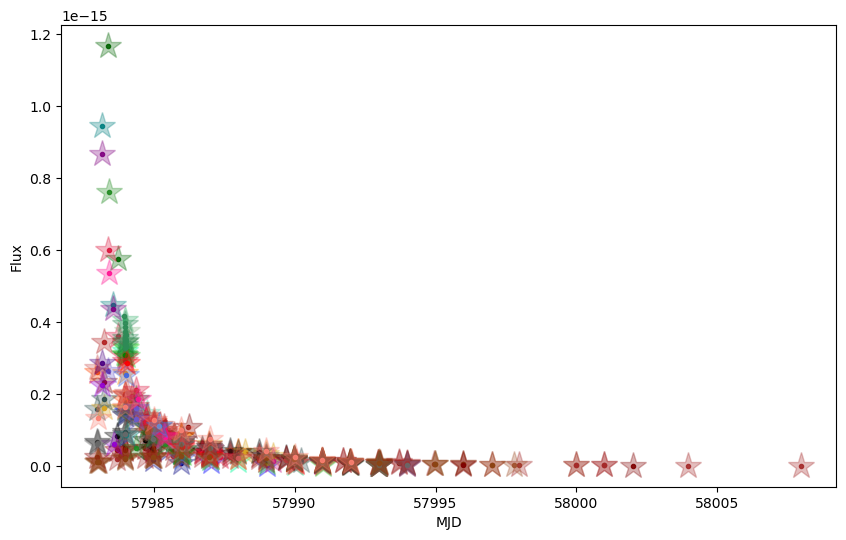

In [33]:
plt.figure(figsize=(10,6))
for filt in SN.avail_filters:
    mask_raw = SN.phot['band'] == filt
    mask_clipped = SN.clipped_phot['band'] == filt
    plt.plot(SN.phot['MJD'][mask_raw], SN.phot['Flux'][mask_raw], 
             '.', label=f'{filt.decode() if isinstance(filt, bytes) else filt} raw', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.9)
    plt.plot(SN.clipped_phot['MJD'][mask_clipped], SN.clipped_phot['Flux'][mask_clipped], 
             '*', markersize=20, label=f'{filt.decode() if isinstance(filt, bytes) else filt} clipped', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.3)

plt.xlabel('MJD')
plt.ylabel('Flux')
#plt.legend()
plt.show()

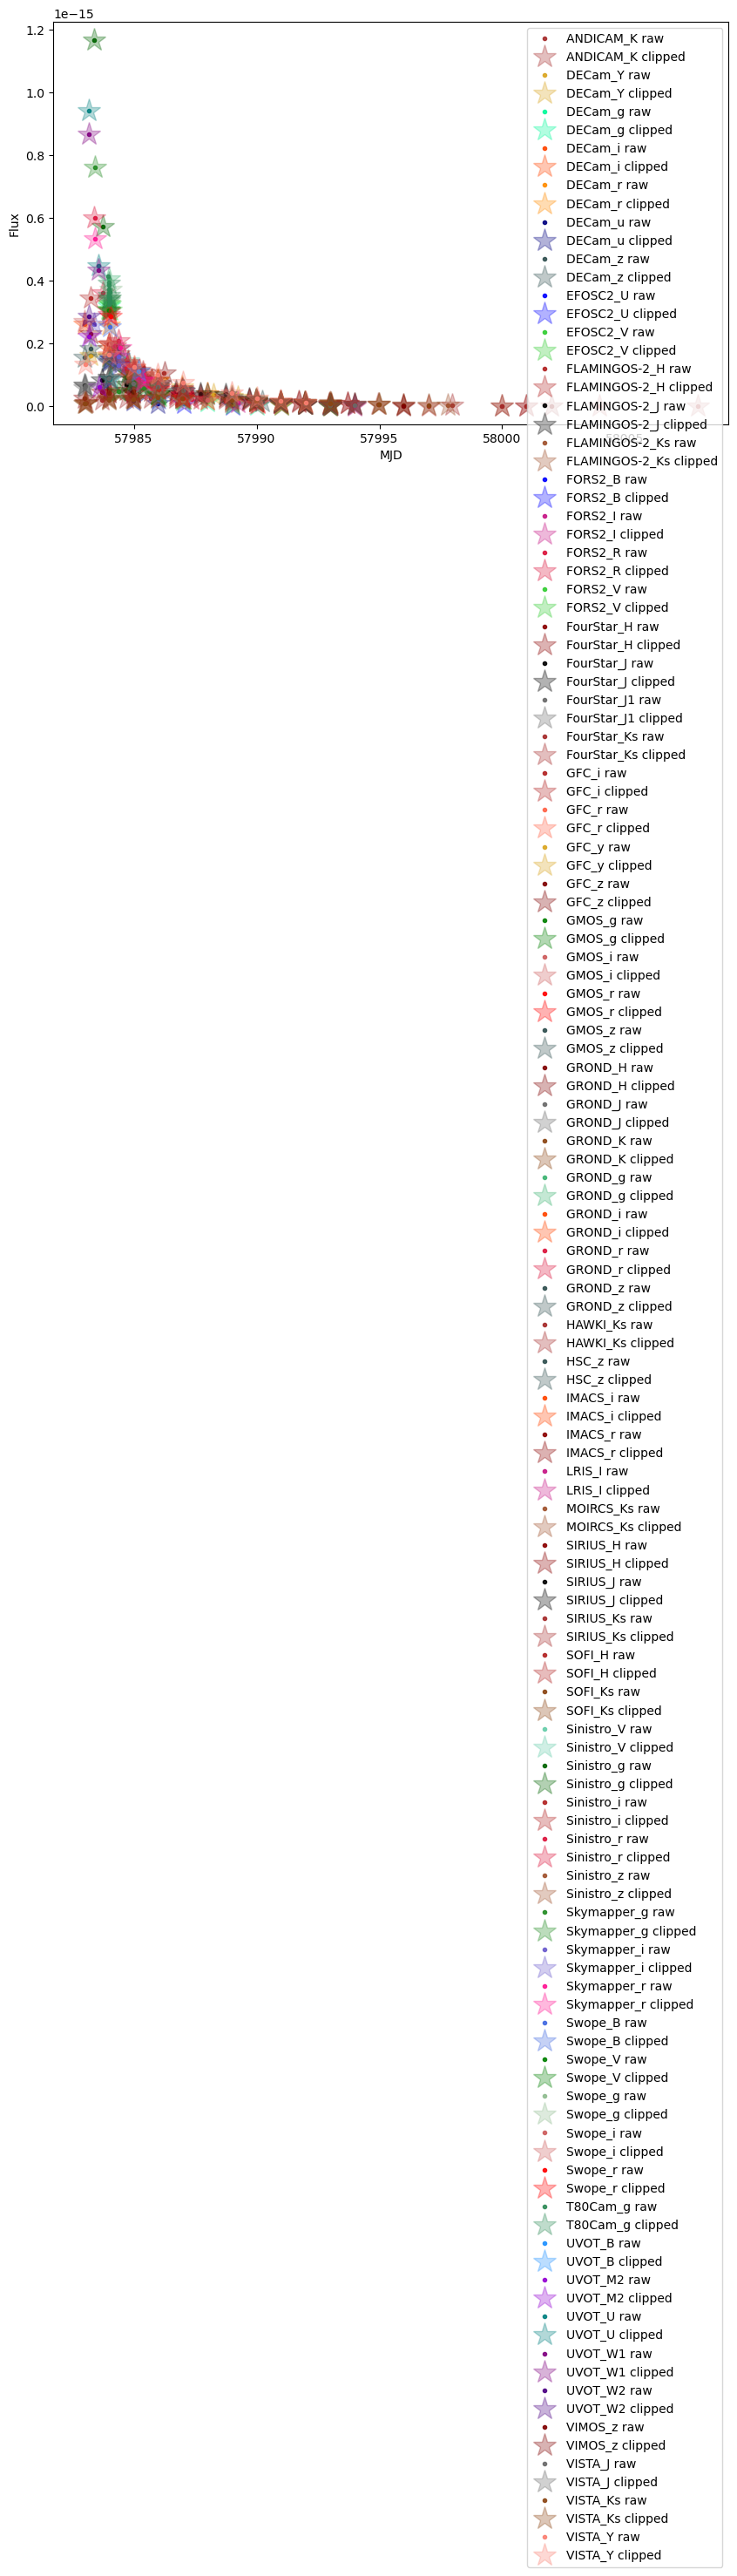

In [34]:
#plt.plot(SN.phot['MJD'], SN.phot['Flux'], '.')
#plt.plot(SN.clipped_phot['MJD'], SN.clipped_phot['Flux'], '.')
plt.figure(figsize=(10,6))
for filt in SN.avail_filters:
    mask_raw = SN.phot['band'] == filt
    mask_clipped = SN.clipped_phot['band'] == filt
    plt.plot(SN.phot['MJD'][mask_raw], SN.phot['Flux'][mask_raw], 
             '.', label=f'{filt.decode() if isinstance(filt, bytes) else filt} raw', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.9)
    plt.plot(SN.clipped_phot['MJD'][mask_clipped], SN.clipped_phot['Flux'][mask_clipped], 
             '*', markersize=20, label=f'{filt.decode() if isinstance(filt, bytes) else filt} clipped', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.3)

plt.xlabel('MJD')
plt.ylabel('Flux')
plt.legend()
plt.show()

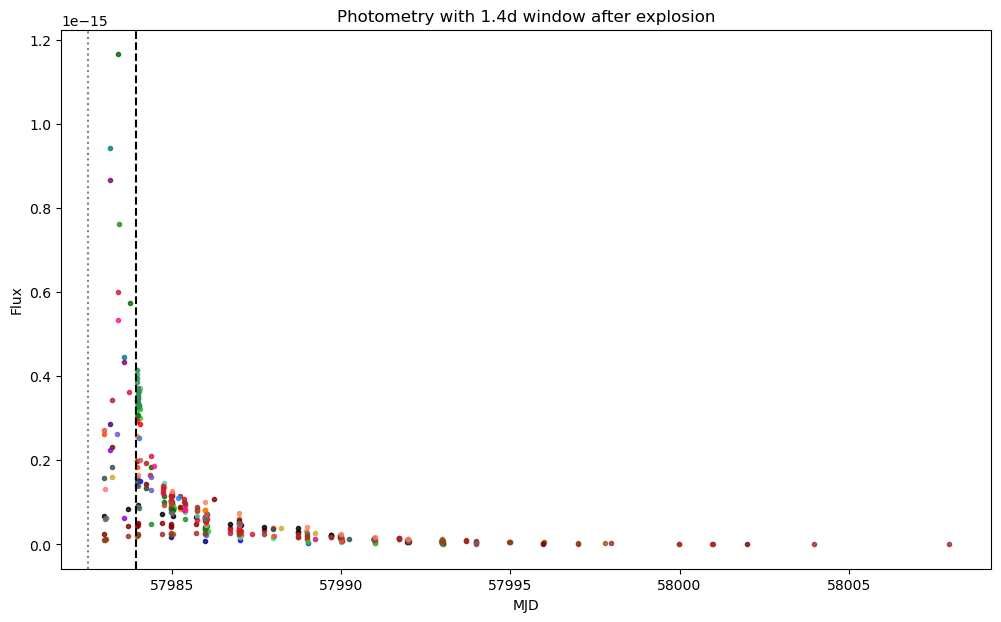

Filters with data within 1.5 days after explosion date:
['DECam_i', 'DECam_z', 'FLAMINGOS-2_Ks', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'GFC_i', 'GFC_y', 'GFC_z', 'HSC_z', 'SIRIUS_H', 'SIRIUS_J', 'SIRIUS_Ks', 'Sinistro_g', 'Sinistro_r', 'Skymapper_g', 'Skymapper_i', 'Skymapper_r', 'Swope_i', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'UVOT_W2', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y']
Filters with data OUTSIDE 1.5 days after explosion date:
['ANDICAM_K', 'DECam_Y', 'DECam_g', 'DECam_r', 'DECam_u', 'EFOSC2_U', 'EFOSC2_V', 'FLAMINGOS-2_H', 'FLAMINGOS-2_J', 'FORS2_B', 'FORS2_I', 'FORS2_R', 'FORS2_V', 'FourStar_J1', 'GFC_r', 'GMOS_g', 'GMOS_i', 'GMOS_r', 'GMOS_z', 'GROND_H', 'GROND_J', 'GROND_K', 'GROND_g', 'GROND_i', 'GROND_r', 'GROND_z', 'HAWKI_Ks', 'IMACS_i', 'IMACS_r', 'LRIS_I', 'MOIRCS_Ks', 'SOFI_H', 'SOFI_Ks', 'Sinistro_V', 'Sinistro_i', 'Sinistro_z', 'Swope_B', 'Swope_V', 'Swope_g', 'Swope_r', 'T80Cam_g', 'UVOT_B', 'VIMOS_z']


In [35]:
explosion_date = explosion_dates[snname][0]
window = 1.4

plt.figure(figsize=(12,7))
filters_within_window = []
filters_outside_window = []

for filt in SN.avail_filters:
    mask = SN.phot['band'] == filt
    mjds = SN.phot['MJD'][mask]
    fluxes = SN.phot['Flux'][mask]
    plt.plot(mjds, fluxes, '.', 
             label=f'{filt.decode() if isinstance(filt, bytes) else filt}', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.8)
    # Check for data within 1.5 days after explosion
    if explosion_date is not None:
        if np.any((mjds >= explosion_date) & (mjds <= explosion_date + window)):
            filters_within_window.append(filt.decode() if isinstance(filt, bytes) else filt)
        else: filters_outside_window.append(filt.decode() if isinstance(filt, bytes) else filt)

if explosion_date is not None:
    plt.axvline(explosion_date + window, color='k', linestyle='--', label=f'Explosion + {window}d')
    plt.axvline(explosion_date, color='gray', linestyle=':', label='Explosion date')

plt.xlabel('MJD')
plt.ylabel('Flux')
#plt.legend()
plt.title(f'Photometry with {window}d window after explosion')
plt.show()

print("Filters with data within 1.5 days after explosion date:")
print(filters_within_window)
print("Filters with data OUTSIDE 1.5 days after explosion date:")
print(filters_outside_window)

## Perform the fit

V band First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57984.0, 30.0, 5.0]
#######################COVARIANCE MATRIX inf


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,


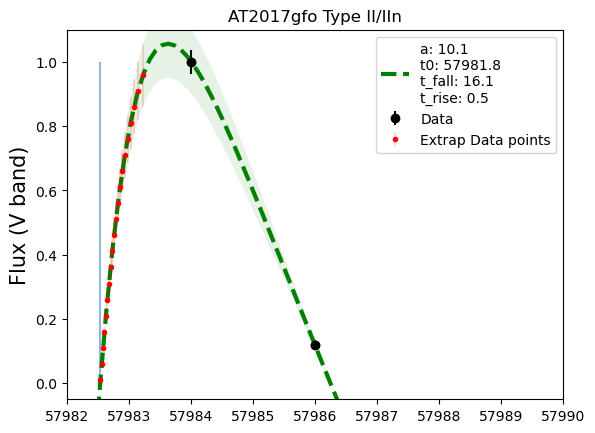

Im extending ONLY these explicitly chosen filters: ['DECam_i', 'DECam_z', 'Swope_i', 'FLAMINGOS-2_Ks', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'GFC_i', 'GFC_y', 'GFC_z', 'HSC_z', 'SIRIUS_H', 'SIRIUS_J', 'SIRIUS_Ks', 'Sinistro_g', 'Sinistro_r', 'Skymapper_r', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y'] 

DECam_i First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.0, 30.0, 5.0]


DECam_z First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.0, 30.0, 5.0]


Swope_i First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57982.98, 30.0, 5.0]


FLAMINGOS-2_Ks First data:-1.96 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57985.02, 30.0, 5.0]


FourStar_H First data:-1.00 Using entire lightcurve
Fitting Forced-Z

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,




GFC_i First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.23, 30.0, 5.0]
#######################COVARIANCE MATRIX inf


GFC_y First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.23, 30.0, 5.0]


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,




GFC_z First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.23, 30.0, 5.0]
#######################COVARIANCE MATRIX inf


HSC_z First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.23, 30.0, 5.0]
#######################COVARIANCE MATRIX inf


SIRIUS_H First data:-1.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57984.7, 30.0, 5.0]


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,




SIRIUS_J First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.7, 30.0, 5.0]


SIRIUS_Ks First data:-2.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57985.7, 30.0, 5.0]


Sinistro_g First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.4, 30.0, 5.0]


Sinistro_r First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.4, 30.0, 5.0]


Skymapper_r First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.42, 30.0, 5.0]
#######################COVARIANCE MATRIX inf


UVOT_M2 First data:0.00 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.16, 30.0, 5.0]
#######################COVARIANCE MATRIX inf


UVOT

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_25184/2902774823.py:183: OptimizeWarning: Covariance of the parameters could not be estimated
  R,cov = opt.curve_fit(fit, t_, flux_, p0=p0,




VISTA_Ks First data:-2.98 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57985.98, 30.0, 5.0]


VISTA_Y First data:-0.98 Using entire lightcurve
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57984.0, 30.0, 5.0]




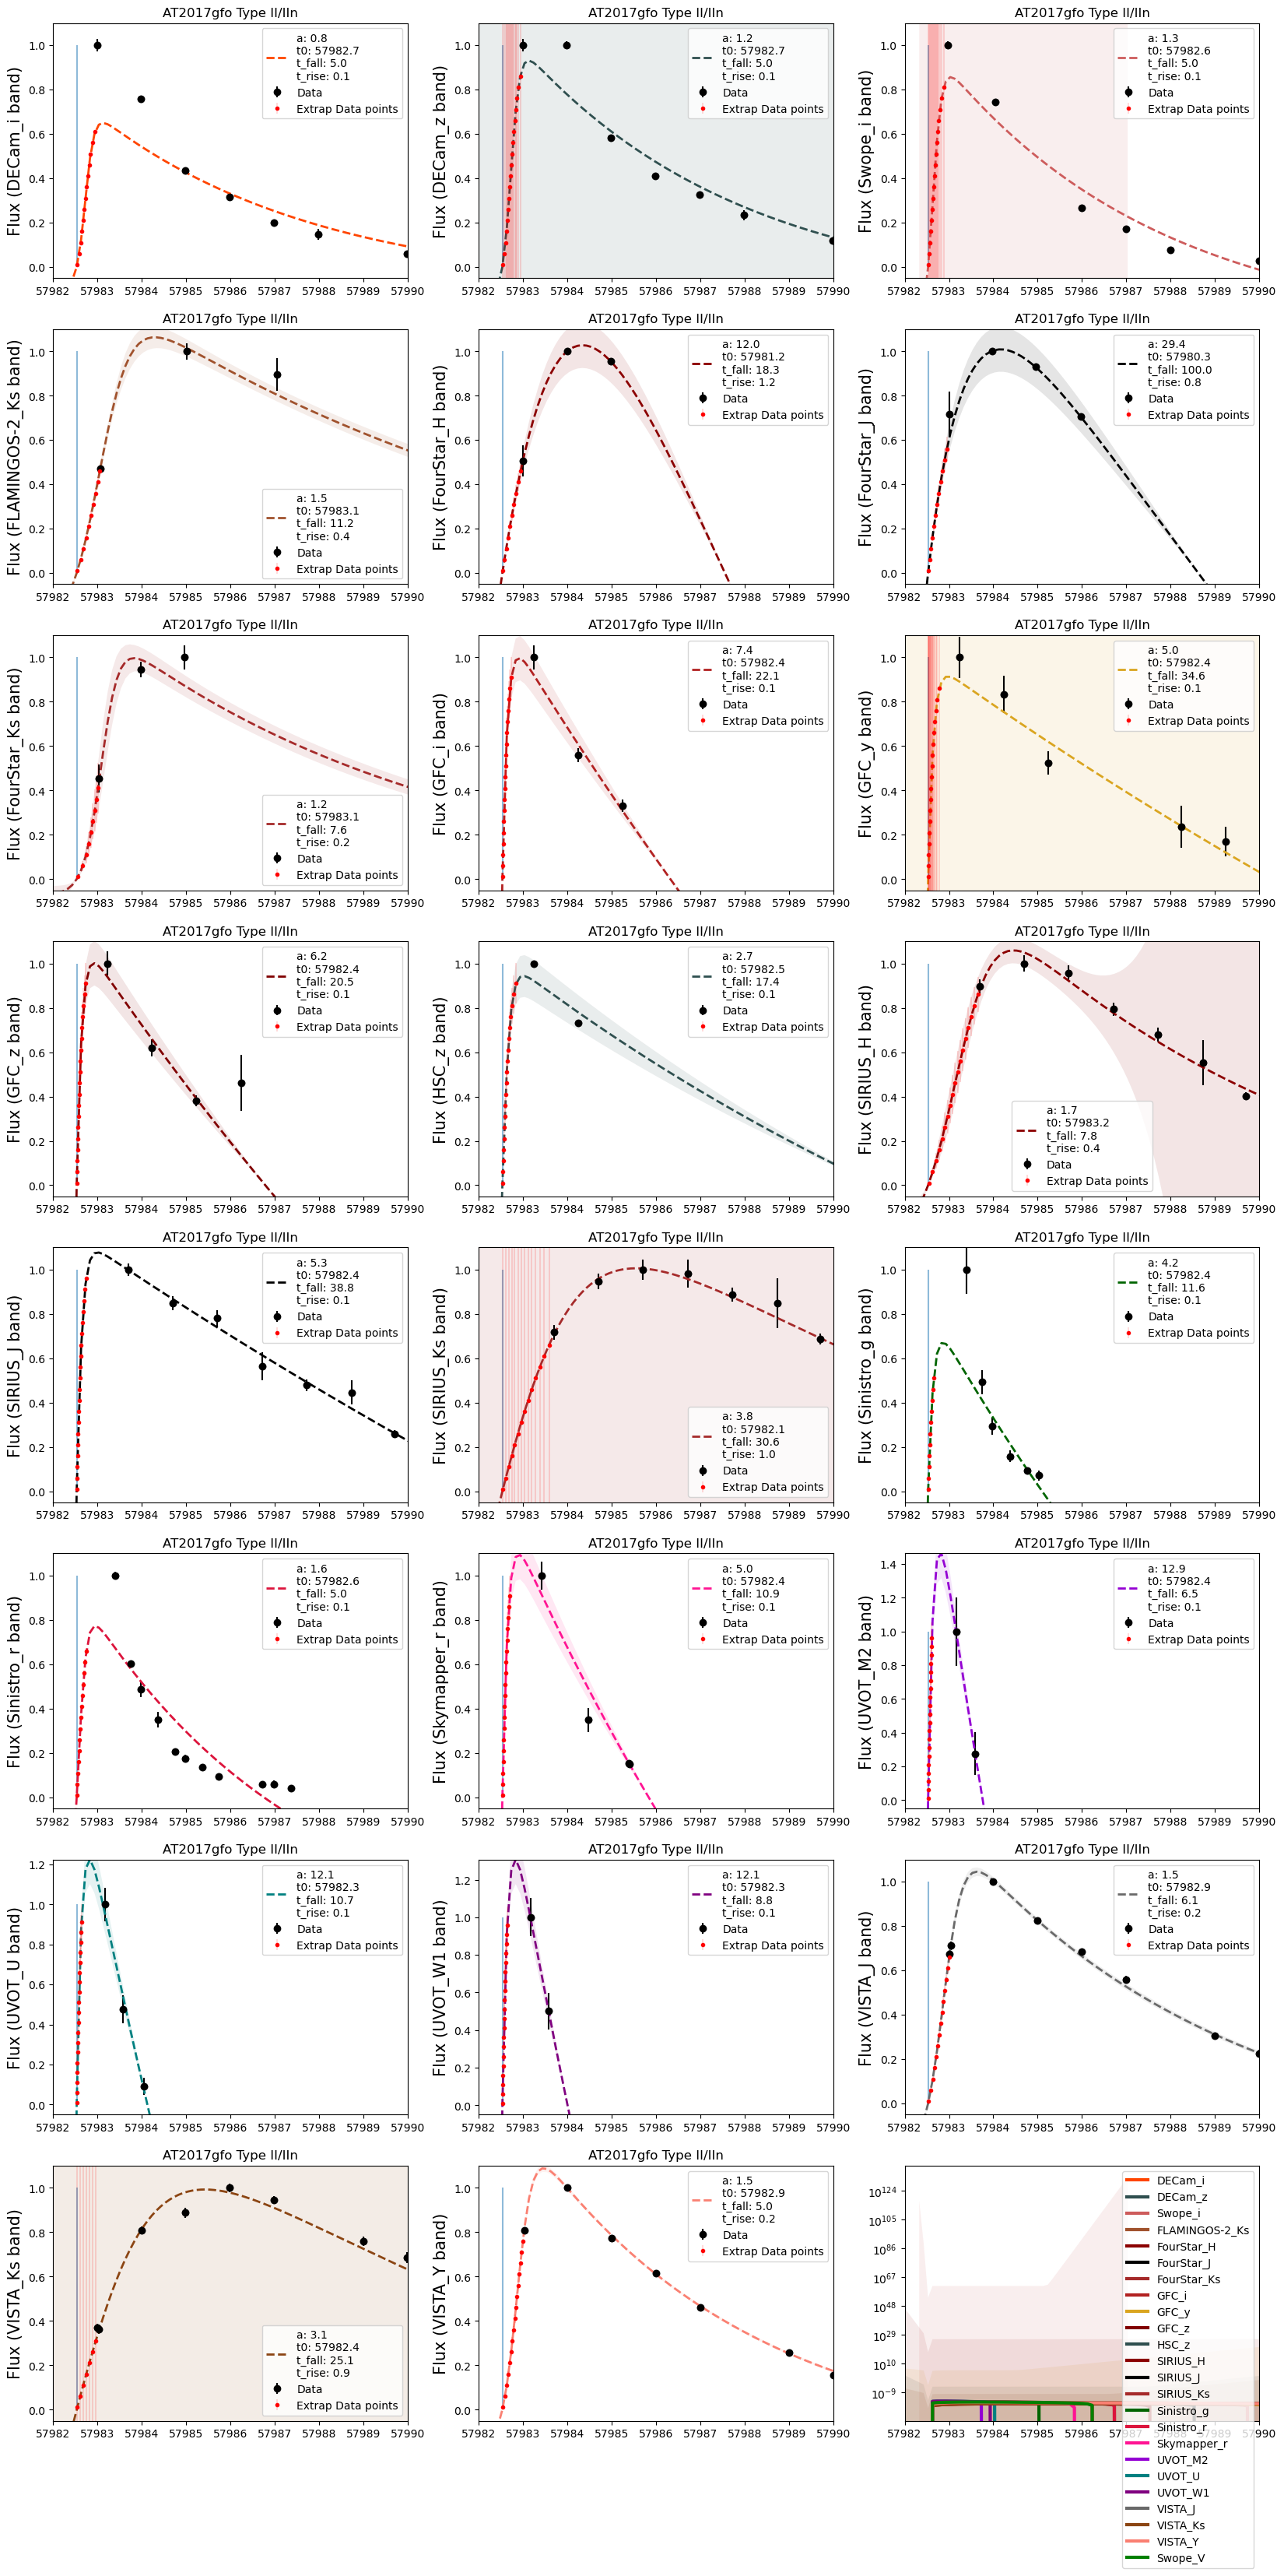

In [50]:
original_phot = pd.DataFrame(SN.phot.copy())
extr_pts_pd = pd.DataFrame(columns=original_phot.columns)#.reindex_like(clipped_phot)[:0]

# Extrapolate BAND V first
#band_init = 'Bessell_V' if snname not in noBessellV_useswiftV else 'swift_V'
band_init = 'Swope_V' if snname not in noBessellV_useswiftV else 'Swope_V'
flux_V = SN.clipped_phot[SN.clipped_phot['band']==band_init]['Flux']
fluxerr_V = SN.clipped_phot[SN.clipped_phot['band']==band_init]['Flux_err']
t_V = SN.clipped_phot[SN.clipped_phot['band']==band_init]['MJD']

mjd_Vpeak = t_V[np.argmax(flux_V)]
Vpeak = max(flux_V)
if snname in pre_bump.keys():
    mjd_Vpeak = explosion_dates[snname][0]+pre_bump[snname][0]
    Vpeak = max(flux_V[t_V>min(t_V)+pre_bump[snname][0]])

plt.plot(t_V, flux_V/Vpeak, 'ok', alpha=0.5)
    
# window = 1.0  # days
# if np.count_nonzero(flux_V[t_V<=mjd_Vpeak]<=0.8*Vpeak)>=2:
#     max_MJD = max(t_V[t_V<=mjd_Vpeak][flux_V[t_V<=mjd_Vpeak]<=0.8*Vpeak])
# else:
#     max_MJD = mjd_Vpeak
#     #max_MJD = min(t_V) + window
# print ('V band', 'First data:%.2f'%(min(t_V)-mjd_Vpeak), 'Max point used for fitting:%.2f'%(max_MJD-mjd_Vpeak))

# t_ = t_V[t_V<=max_MJD]
# phase_ = t_ - mjd_Vpeak
# flux_ = flux_V[t_V<=max_MJD]/Vpeak
# fluxerr_ = fluxerr_V[t_V<=max_MJD]/Vpeak
# plt.vlines(max_MJD, 0,1, linestyle=':', alpha=0.5)

print ('V band', 'First data:%.2f'%(min(t_V)-mjd_Vpeak), 'Using entire lightcurve')

t_ = np.array(t_V)
phase_ = t_ - mjd_Vpeak
flux_ = np.array(flux_V)/Vpeak
fluxerr_ = np.array(fluxerr_V)/Vpeak

# FIT
R, cov, t_extrapV, fittedV, fittedV_err, t_newpts, newpts_, newpts_err, label_dict, success = performe_fit(snname, band_init, t_, flux_, fluxerr_, phase_, mjd_Vpeak)
    
plt.errorbar(t_, flux_, yerr=fluxerr_, fmt='ok', label='Data')
plt.ylabel('Flux (V band)', fontsize=15)
        
plt.plot(t_extrapV, fittedV, 'g--', lw=3, label='\n'.join("%s: %.1f"%(k,v) for (k,v) in label_dict))
plt.fill_between(t_extrapV, fittedV-fittedV_err, fittedV+fittedV_err,
                 facecolor='g', alpha=0.1)

plt.errorbar(t_newpts, newpts_, yerr=newpts_err, fmt='r.', ecolor='r', elinewidth=0.2, label='Extrap Data points')

plt.xlim(min(min(t_extrapV)-5., -25.+mjd_Vpeak),30.+mjd_Vpeak)
if snname in pre_bump.keys(): plt.xlim((explosion_dates[snname][0]-2.),20.+mjd_Vpeak)
    
if snname in se_sne: plt.title(snname+ '_SESN')
else: plt.title(snname+ ' Type II/IIn')
plt.ylim(-0.05, max(max(fittedV),1.1))
plt.xlim(57982, 57990)
plt.legend()
plt.show()
    
if success:
    extr_pts_pd['MJD'] = t_newpts
    extr_pts_pd['band'] = np.full(len(t_newpts), fill_value=band_init)
    extr_pts_pd['Flux'] = newpts_*Vpeak
    extr_pts_pd['Flux_err'] = newpts_err*Vpeak
    extr_pts_pd['FilterSet'] = np.full(len(t_newpts), fill_value='SUDO_PTS')
    extr_pts_pd['Instr'] = np.full(len(t_newpts), fill_value='SUDO_PTS')
    #original_phot = original_phot.append(extr_pts_pd)
    original_phot = pd.concat([original_phot, extr_pts_pd], ignore_index=True)
else: print ('Something went wrong')
    
i=1
early_bands=[]
exclude_bands = exclude_dict[snname] if snname in exclude_dict else []
include_bands = include_dict[snname] if snname in include_dict else []
#print(np.unique(SN.clipped_phot['band']))
# for band in np.unique(SN.clipped_phot['band']):
#     t_x = SN.clipped_phot[SN.clipped_phot['band']==band]['MJD']
#     #print(f"{band}: min(t_x)={min(t_x)}, min(t_V)={min(t_V)}, max_MJD={max_MJD}, t_x_before_maxMJD={t_x[t_x<=max_MJD]}")
#     #if (min(t_x)<=min(t_V)+2.0)&(len(t_x[t_x<=max_MJD])>=1):
#     #rav changed this line
#     # rav removing this line again 2/25/26, to add the new logic
#     # if (min(t_x)<=min(t_V)+2.0)&(len(t_x[t_x<=max(t_V)+1.0])>=1):

#     # NEW: Determine the absolute start date (fallback to first V observation if undefined)
#     start_date = explosion_dates[snname][0]
#     if start_date is None: 
#         start_date = min(t_V)

#     # Only include filters that have data within 1.5 days of the start date
#     if (min(t_x) - start_date <= 1.3):
#         if (snname in se_sne)&(band not in [band_init, 'swift_UVW1','swift_UVW2', 'swift_UVM2'])&(band not in exclude_bands):
#             early_bands.append(band)
#         elif (snname not in se_sne)&(band not in [band_init, 'swift_U', 'Bessell_U', 'swift_UVW1',
#                                            'swift_UVW2', 'swift_UVM2'])&(band not in exclude_bands):
#             early_bands.append(band)
#     if (band in include_bands):
#         if band not in early_bands: early_bands.append(band)

# N_rows = int(len(early_bands)/3)+1
# fig = plt.figure(figsize=(20,N_rows*5))
# print(early_bands)
# print ('Im extending also', early_bands, '\n')

# --- EXPLICIT FILTER SELECTION ---
# Define exactly which filters to fit. This bypasses the automated 1.3-day cutoff logic.
early_bands = ['DECam_i', 'DECam_z', 'Swope_i', 'FLAMINGOS-2_Ks', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'GFC_i', 'GFC_y', 'GFC_z', 
                'HSC_z', 'SIRIUS_H', 'SIRIUS_J', 'SIRIUS_Ks', 'Sinistro_g', 'Sinistro_r', 'Skymapper_r', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 
                'VISTA_J', 'VISTA_Ks', 'VISTA_Y'] # <-- Modify this list with your filters of choice

N_rows = int(len(early_bands)/3)+1
fig = plt.figure(figsize=(20,N_rows*5))
print ('Im extending ONLY these explicitly chosen filters:', early_bands, '\n')

for band in early_bands:
    plt.subplot(N_rows,3,i)
    
    flux_x = SN.clipped_phot[SN.clipped_phot['band']==band]['Flux']
    fluxerr_x = SN.clipped_phot[SN.clipped_phot['band']==band]['Flux_err']
    t_x = SN.clipped_phot[SN.clipped_phot['band']==band]['MJD']
    xpeak = max(flux_x)
    mjd_xpeak = t_x[np.argmax(flux_x)]
    if snname in pre_bump.keys():
        mjd_xpeak = explosion_dates[snname][0]+pre_bump[snname][0]
        xpeak = max(flux_x[t_x>mjd_xpeak])
        
    plt.plot(t_x, flux_x/xpeak, 'ok', alpha=0.5)
    
    # Replacing this!!!
    # if np.count_nonzero(flux_x[t_x<=mjd_xpeak]<=0.8*xpeak)>=2:
    #     max_MJD = max(t_x[t_x<=mjd_xpeak][flux_x[t_x<=mjd_xpeak]<=0.8*xpeak])
    # else:
    #     max_MJD = mjd_xpeak
    # print (band, 'First data:%.2f'%(min(t_x)-mjd_xpeak), 'Max point used for fitting:%.2f'%(max_MJD-mjd_xpeak))

    # t_ = t_x[t_x<=max_MJD]
    # phase_ = t_ - mjd_xpeak
    # flux_ = flux_x[t_x<=max_MJD]/xpeak
    # fluxerr_ = fluxerr_x[t_x<=max_MJD]/xpeak
    # #plt.xlim(min(min(t_extrapV)-5., -25.+mjd_Vpeak),30.+mjd_Vpeak)
    # plt.xlim(57982, 57990)
    # if snname in pre_bump.keys(): plt.xlim((explosion_dates[snname][0]-2.),20.+mjd_Vpeak)
    # plt.vlines(max_MJD, 0,1, linestyle=':', alpha=0.5)

    #NEW!!!
    print (band, 'First data:%.2f'%(min(t_x)-mjd_xpeak), 'Using entire lightcurve')

    t_ = np.array(t_x)
    phase_ = t_ - mjd_xpeak
    flux_ = np.array(flux_x)/xpeak
    fluxerr_ = np.array(fluxerr_x)/xpeak
    
    plt.xlim(57982, 57990)
    if snname in pre_bump.keys(): plt.xlim((explosion_dates[snname][0]-2.),20.+mjd_Vpeak)

    results = performe_fit(snname, band, t_, flux_, fluxerr_, phase_, mjd_xpeak)
    R, cov, t_extrap, fitted, fitted_err, t_newpts, newpts_, newpts_err, label_dict, success= results
    
    plt.errorbar(t_, flux_, yerr=fluxerr_, fmt='ok', label='Data')
    
    plt.ylabel('Flux (%s band)'%band, fontsize=15)
    plt.plot(t_extrap, fitted, '--', color=color_dict[band], lw=2,
             label='\n'.join("%s: %.1f"%(k,v) for (k,v) in label_dict))
    plt.fill_between(t_extrap, fitted-fitted_err, fitted+fitted_err,
                 facecolor=color_dict[band], alpha=0.1)
    plt.errorbar(t_newpts, newpts_, yerr=newpts_err, fmt='r.', ecolor='r', elinewidth=0.2, label='Extrap Data points')
    plt.ylim(-0.05, max(max(fitted),1.1))
    
    if snname in se_sne: plt.title(snname+ '_SESN')
    else: plt.title(snname+ ' Type II/IIn')
    plt.legend()
    i=i+1
   
    if success:
        extr_pts_pd = pd.DataFrame(columns=original_phot.columns)#.reindex_like(clipped_phot)[:0]
        extr_pts_pd['MJD'] = t_newpts
        extr_pts_pd['band'] = np.full(len(t_newpts), fill_value=band)
        extr_pts_pd['Flux'] = newpts_ * xpeak
        extr_pts_pd['Flux_err'] = newpts_err * xpeak
        extr_pts_pd['FilterSet'] = np.full(len(t_newpts), fill_value='SUDO_PTS')
        extr_pts_pd['Instr'] = np.full(len(t_newpts), fill_value='SUDO_PTS')
        #original_phot = original_phot.append(extr_pts_pd) 
        original_phot = pd.concat([original_phot, extr_pts_pd], ignore_index=True)
    else: print ('Something went wrong')
    
    plt.subplot(N_rows,3,N_rows*3)
    plt.plot(t_extrap, fitted*xpeak, '-', color=color_dict[band], lw=3, label=band)
    plt.fill_between(t_extrap, (fitted-fitted_err)*xpeak, (fitted+fitted_err)*xpeak,
                         facecolor=color_dict[band], alpha=0.1)
    print ('\n')
plt.subplot(N_rows,3,N_rows*3)
plt.plot(t_extrapV, fittedV*Vpeak, '-', color=color_dict['Swope_V'], lw=3,
                 label='Swope_V')
plt.fill_between(t_extrapV, Vpeak*(fittedV-fittedV_err), Vpeak*(fittedV+fittedV_err),
                     facecolor=color_dict[band], alpha=0.1)
#plt.xlim(min(min(t_extrapV)-3., -25.+mjd_Vpeak),10.+mjd_Vpeak)
plt.xlim(57982, 57990)

plt.legend()
plt.yscale('log')
plt.xlim(57982, 57990)
plt.show()
plt.close(fig)
    
# original_phot.to_csv(OUTPUT_PATH+'/%s.dat'%snname, na_rep='nan',
#               index=False, sep='\t')

# --- CONVERT DATA TO LOG-SPACE BEFORE SAVING ---
# 1. Calculate Phase (time since explosion)
t0_fix = explosion_dates[snname][0]
original_phot['Phase'] = original_phot['MJD'] - t0_fix

# 2. Filter out pre-explosion points (Phase < 0) which break log-time
original_phot = original_phot[original_phot['Phase'] >= 0].copy()

# 3. Safeguard against log10(0) = -inf at the exact explosion time
original_phot.loc[original_phot['Phase'] == 0, 'Phase'] = 1e-5 

# 4. Safeguard against log10(0) = -inf for the zero-flux points we just modeled
original_phot = original_phot[original_phot['Flux'] >= 0].copy()
original_phot.loc[original_phot['Flux'] == 0, 'Flux'] = 1e-25

# 5. Apply transformations
original_phot['Log_Phase'] = np.log10(original_phot['Phase'])
original_phot['Log_Flux'] = np.log10(original_phot['Flux'])

# 6. Propagate flux errors into log space: error_log = error_linear / (Flux * ln(10))
original_phot['Log_Flux_err'] = original_phot['Flux_err'] / (original_phot['Flux'] * np.log(10))

# --- FINAL SANITIZATION BEFORE SAVING ---
# 1. Catch infs or NaNs in the linear flux error and fallback to 10% of the flux
original_phot['Flux_err'] = np.where(
    np.isinf(original_phot['Flux_err']) | np.isnan(original_phot['Flux_err']), 
    0.1 * np.abs(original_phot['Flux']), 
    original_phot['Flux_err']
)

# 2. Recalculate the log flux error using the newly sanitized linear error
if 'Log_Flux' in original_phot.columns:
    original_phot['Log_Flux_err'] = original_phot['Flux_err'] / (original_phot['Flux'] * np.log(10))

# 3. Absolute catch-all: replace any straggling infs with NaN so they don't break downstream tools
original_phot.replace([np.inf, -np.inf], np.nan, inplace=True)

# Save the final log-ready dataframe
original_phot.to_csv(OUTPUT_PATH+'/%s.dat'%snname, na_rep='nan',
              index=False, sep='\t')

# Save the final log-ready dataframe
original_phot.to_csv(OUTPUT_PATH+'/%s.dat'%snname, na_rep='nan',
              index=False, sep='\t')

In [15]:
print(np.unique(SN.clipped_phot['band']))
print([type(b) for b in np.unique(SN.clipped_phot['band'])])

['ACS_WFC_F475W' 'ACS_WFC_F625W' 'ACS_WFC_F775W' 'ACS_WFC_F850W' 'DECam_Y'
 'DECam_g' 'DECam_i' 'DECam_r' 'DECam_u' 'DECam_z' 'EFOSC2_U' 'EFOSC2_V'
 'FourStar_H' 'FourStar_J' 'FourStar_J1' 'FourStar_Ks' 'LRIS_I'
 'RetroCam_H' 'RetroCam_J' 'RetroCam_Y' 'SOFI_H' 'SOFI_Ks' 'Sinistro_g'
 'Sinistro_i' 'Sinistro_r' 'Sinistro_w' 'Sinistro_z' 'Swope_B' 'Swope_V'
 'Swope_g' 'Swope_i' 'Swope_r' 'UVOT_U' 'WFC3_IR_F110W' 'WFC3_IR_F160W'
 'WFC3_UVIS1_F336W' 'skymapper_g' 'skymapper_i' 'skymapper_r']
[<class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <class 'numpy.str_'>, <

In [22]:
# Read the CSV file
df = pd.read_csv("/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Photometry/4_LCs_late_extrapolated/AT2017gfo.dat", sep=',')  # comma-separated by default

# Save as TSV (tab-separated)
df.to_csv("/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Photometry/4_LCs_late_extrapolated/AT2017gfo.dat", sep="\t", index=False)